<a href="https://colab.research.google.com/github/juan-torresf/PDI/blob/main/PDI_AF2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Equipo 4
* Benito Woo Zozaya 2177866
* Karen Melissa Morales Moya 2043909
* Carlos Arturo Arguelles Segura 2096281
* Juan Gerardo Torres Flores 2074382

In [17]:
#Librerias
import kagglehub
import numpy as np
import kagglehub
import cv2 as cv
import os
from google.colab.patches import cv_imshow
from matplotlib import pyplot as plt
from google.colab import files

### Cargar Imagenes
Para las imagenes vamos a utilizar un dataset de kaggle llamado Brain Tumor MRI Dataset, el cual tiene imagenes de diferentes tumores de cerebro y algunas limpias, regularmente utilizado para entrenar CNN redes neuronales convulacionales, del cual utilizaremos una imagen de un glioma.

In [18]:
#Cargar imagenes
# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

#elegir imagen
image_path = os.path.join(path, 'Testing', 'glioma','Te-gl_1.jpg')
#a. Utiliza cv2.imread() para abrir la imagen en color y en escala de grises.
img_color = cv.imread(image_path)
#b. Obtén las dimensiones de la imagen con img.shape
print("Image Dimensions: ", img_color.shape)


Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
Image Dimensions:  (442, 354, 3)


### Preprocesamiento
Una vez elegida la imagen se utilizará la función de cv2.COLOR_BGR2GRAY que convierte la imagen de colores a grises, enseguida se utilizarán diferentes tecnicas para ajustar el brillo y el contraste para encontrar la mejor calidad para la segmentación, probamos con aumentarle la exposición de luz con sumas y restas así como aplicar filtros pasa bajas (y un gaussiano) para corregir zonas muertas, aunque no fue necesario pues con ecualización de tonos fue suficiente para mejorar el contraste en este caso <br>
De igual manera se muestran los tonos de grises antes y después de la ecualización

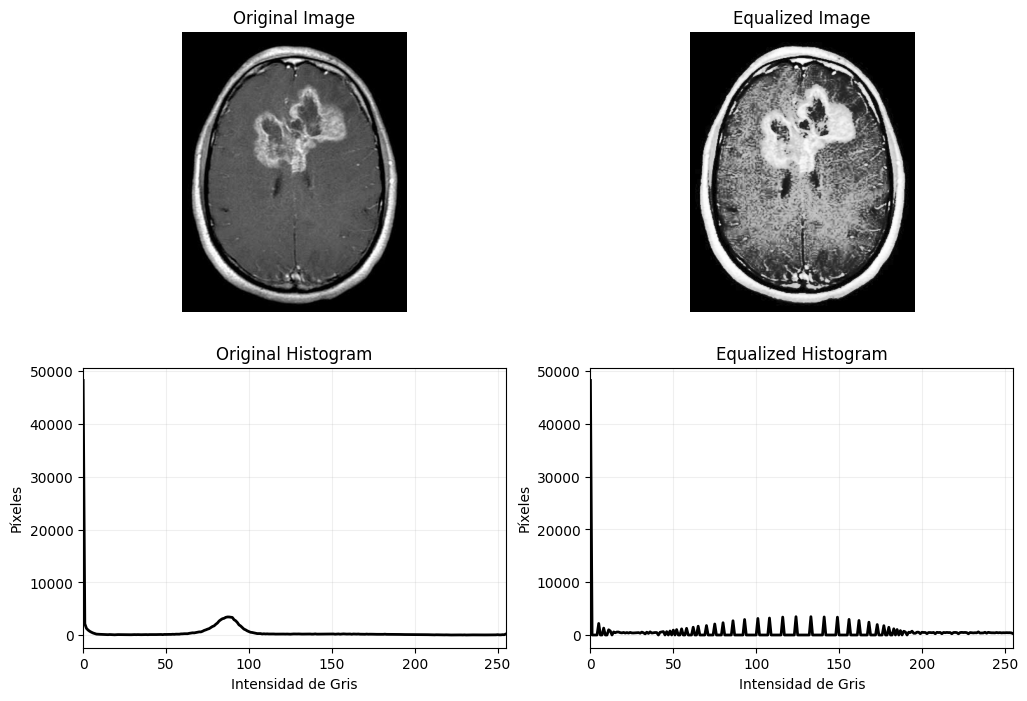

In [19]:
#2.    Preprocesamiento:
#a. Convertir la imagen a escala de grises con cv2.cv2tColor(img, cv2.COLOR_BGR2GRAY).
img_grayscale = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

#b Ajustar el brillo y contraste de la imagen con alguna de las operaciones que
#vimos en clase (aritméticas, lógicas, ecualización de histograma, etc.).

equalized_image = cv.equalizeHist(img_grayscale)
exposure_image = cv.add(img_grayscale, 50)
substraction_image = cv.subtract(img_grayscale, 65)
filtro_pasa_baja_image= cv.medianBlur(equalized_image, 7)
gaussiano_image = cv.GaussianBlur(img_grayscale, (15, 15), 0)

#utilizamos ravel para aplanar la matriz a un solo vector pero de manera que solo genere un puntero
img_grayscale_histogram, _= np.histogram(img_grayscale.ravel(), bins=256, range = (0, 256))
equalized_image_histogram, _ = np.histogram(equalized_image.ravel(), bins=256, range = (0, 256))

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(img_grayscale, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.plot(img_grayscale_histogram, color='black', linewidth=2)
plt.title('Original Histogram')
plt.xlabel('Intensidad de Gris')
plt.ylabel('Píxeles')
plt.xlim([0, 255])
plt.grid(True, alpha=0.2)

plt.subplot(2, 2, 4)
plt.plot(equalized_image_histogram, color='black', linewidth=2)
plt.title('Equalized Histogram')
plt.xlabel('Intensidad de Gris')
plt.ylabel('Píxeles')
plt.xlim([0, 255])
plt.grid(True, alpha=0.2)

### Segmentación

Despúes del preprocesamiento se va a segmentar la imagen en blanco y negro (binario) donde negro es vació y lo blanco será nuestra area de interés. <br>
Esto genera lo que llamamos una mascara la cual uniremos posteriormente a la imagen original, para esto se utilizó un valor de gris de 10 para el umbral, el cual nos permite identificar que valores por debajo del umbral se tomarán como 0 logicos mientras que valores arriba de 10 se consideran 1 logicos. <br>
Después se separa de la imagen original los canales de color azul, verde y rojo y se muestra en un histograma. <br>
Aunque en este solo se note el color azul, los 3 colores están presentes en la misma cantidad en esta imagen pues estaba practicamente ya en escala de grises, por lo que en cada pixel hay la misma cantidad de lso 3 colores.

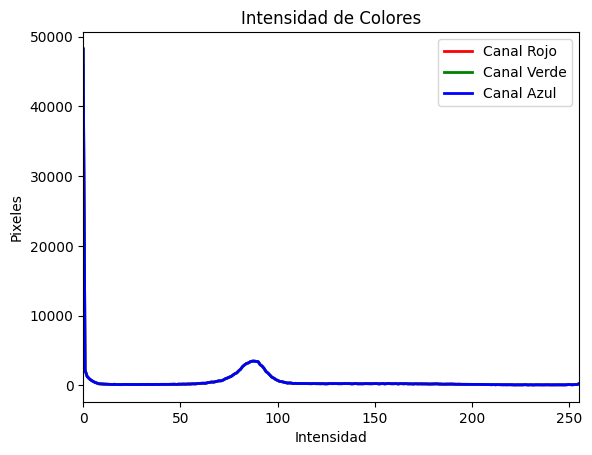

In [20]:
#3.Segmentación:
#a.Aplicar umbralización con cv2.threshold(img_gray, valor_umbral, 255, cv2.THRESH_BINARY_INV).
threshold_value = 10
max_value = 255
_, binary_segmented_image = cv.threshold(equalized_image, threshold_value, max_value, cv.THRESH_BINARY)

image = cv.bitwise_and (img_color, img_color, mask=binary_segmented_image)


#b.Separar los canales de la imagen RGB con b, g, r = cv2.split(img_color).
b, g, r = cv.split(img_color)

#utilizamos las matrices de los canales bgr para mostrarlos en un histograma

hist_r, _ = np.histogram(r.ravel(), bins=256, range=(0, 256))
hist_g, _ = np.histogram(g.ravel(), bins=256, range=(0, 256))
hist_b, _ = np.histogram(b.ravel(), bins=256, range=(0, 256))

plt.plot(hist_r, color='red', linewidth=2, label='Canal Rojo')
plt.plot(hist_g, color='green', linewidth=2, label='Canal Verde')
plt.plot(hist_b, color='blue', linewidth=2, label='Canal Azul')

plt.title('Intensidad de Colores')
plt.xlabel('Intensidad')
plt.ylabel('Pixeles')
plt.xlim([0, 255])
plt.legend()

plt.show()

### Impresiones

Aqui se pueden observar los diferentes filtros y contrastes realizados a la imagen, así como la imagen segmentada y la final.

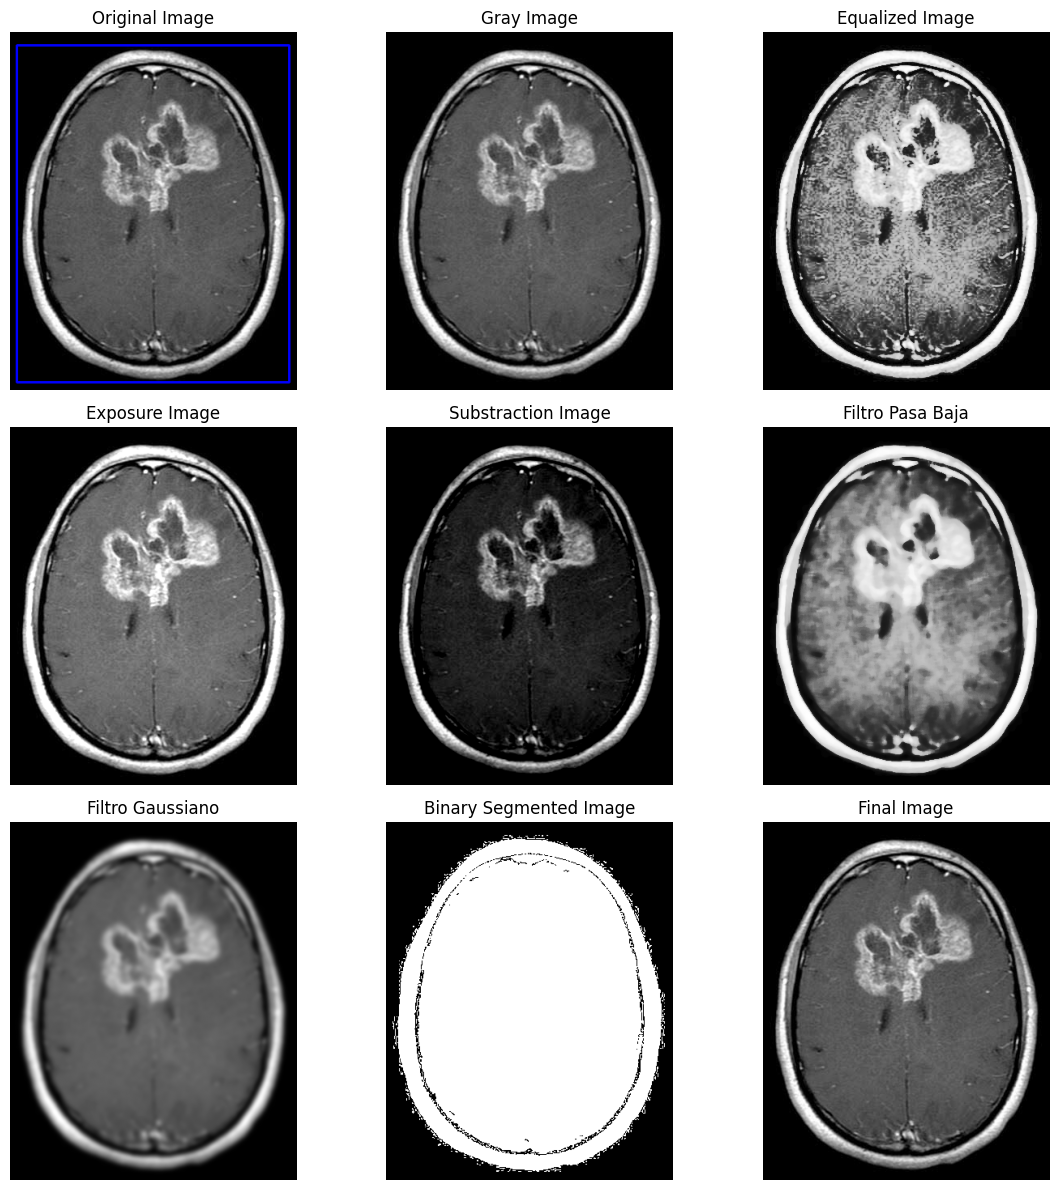

In [23]:
#impresiones
plt.figure(figsize=(12, 12))

plt.subplot(3, 3, 1)
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB)) # CONVERTIMOS EL BRG A RGB
plt.title('Original Image')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(img_grayscale, cmap='gray')
plt.title('Gray Image')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(exposure_image, cmap='gray')
plt.title('Exposure Image')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(substraction_image, cmap='gray')
plt.title('Substraction Image')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(filtro_pasa_baja_image, cmap='gray')
plt.title('Filtro Pasa Baja')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(gaussiano_image, cmap='gray')
plt.title('Filtro Gaussiano')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(binary_segmented_image, cmap='gray')
plt.title('Binary Segmented Image')
plt.axis('off')

plt.subplot(3, 3, 9)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Final Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### Analisis de Caracteristicas

Aquí podemos observar el tamaño de la imagen tras ser procesada utilizado np.count_nonzero, que cuenta todos los pixeles blancos en este caso y el espacio minimo donde puede ser contenida la imagen segmentada.

Area:  104748
Bounding Box:  8   16   336   416


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
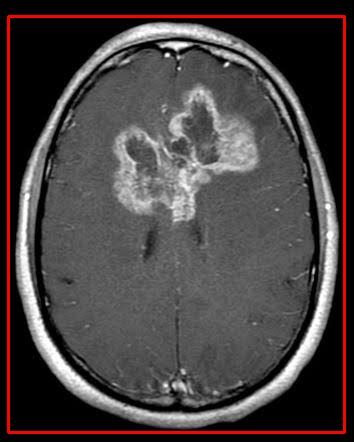

In [22]:
#4.Análisis de características:
#a.Obtener el área del objeto segmentado con np.count_nonzero(img_bin).
area = np.count_nonzero(binary_segmented_image)
print("Area: ", area)
#b.Extraer el bounding box del objeto con x, y, w, h = cv2.boundingRect(img_bin).
x, y, w, h = cv.boundingRect(binary_segmented_image)
print("Bounding Box: ", x, " ", y, " ", w, " ", h)

#c.Dibujar el bounding box con cv2.rectangle(img_color, (x, y), (x + w, y + h), (255, 0, 0), 2).
cv.rectangle(img_color, (x, y), (x + w, y + h), (255, 0, 0), 2)